# Part 2 — Multi-armed bandits: each strategy is a slot machine

**Analogy.** You walk into a casino with 8 slot machines ("one-armed bandits"). Each pays out
from its own hidden distribution. You have 1,000 pulls. How do you find the best machine
*while* making as much money as possible along the way?

**Our problem.** Each Monday you pull one "arm", meaning you deploy one strategy, and a week later
you see its P&L. You never see what the other arms would have paid. We **ignore market
features** for now: this bandit doesn't look at VIX or trend. (Adding features is Part 3.) So
the best it can do is find the single strategy with the best **long-run average**.

**Why start here?** Bandits isolate the one problem that makes RL different from supervised
learning: **exploration vs exploitation**. Everything later builds on it.

Our bandit is realistic. Each arm pays a random draw from that strategy's 20-year history of
weekly P&L: fat tails, skew and all.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import optrl
from optrl import metrics as M
M.set_style()
market = optrl.load_default_market()
table = optrl.weekly_pnl_table(market)
bandit = optrl.StrategyBandit(table, seed=0)
A = bandit.names
truth = pd.DataFrame({"mean $/wk": bandit.true_means, "std $/wk": table.std().values}, index=A)
print(truth.round(0))
print("\nBest arm:", A[bandit.best_arm])

                  mean $/wk  std $/wk
no_trade                0.0       0.0
short_straddle         46.0     301.0
iron_condor            24.0     295.0
bull_put_spread        51.0     315.0
bear_call_spread       24.0     339.0
long_straddle        -190.0     756.0
bull_call_spread     -116.0    1178.0
bear_put_spread      -277.0    1116.0

Best arm: bull_put_spread


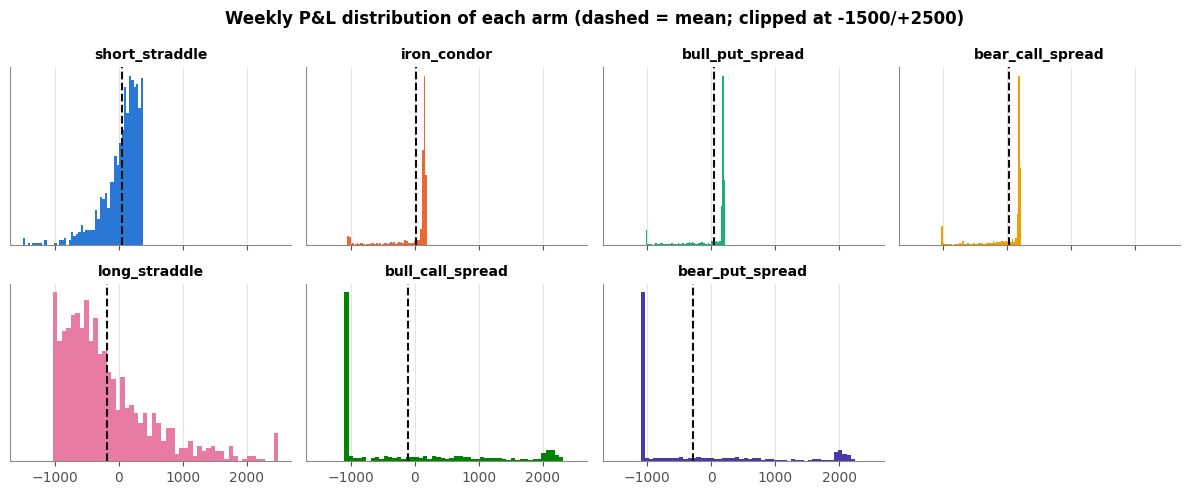

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True)
for ax, a in zip(axes.flat, A[1:]):
    ax.hist(table[a].clip(-1500, 2500), bins=50, color=M.ACTION_COLORS[a])
    ax.axvline(table[a].mean(), color="#0b0b0b", lw=1.5, ls="--")
    ax.set_title(a, fontsize=10); ax.set_yticks([])
axes.flat[-1].axis("off")
fig.suptitle("Weekly P&L distribution of each arm (dashed = mean; clipped at -1500/+2500)", fontweight="bold")
plt.tight_layout(); plt.show()

**Look at the shapes.** Premium sellers (short straddle, condor, credit spreads) pile up near
small wins with a long left tail. Debit strategies are two-humped: they lose the debit or win big.
The best arm by mean (bull put spread, about \$51/week) is **small next to the noise** (a std
around \$300/week). Distinguishing arms whose means differ by \$20 when the noise is \$300
takes hundreds of samples. That's the whole difficulty.

---
## 2.1 Estimating an arm's value: the incremental mean

The value of arm *a* is its expected reward, $q_*(a) = \mathbb{E}[R \mid a]$. We estimate it
with the average of the rewards seen so far, $Q(a)$. To avoid storing every reward, update the
average **incrementally**:

$$ Q_{n+1} = Q_n + \frac{1}{n}\,\big(R_n - Q_n\big) $$

*In words:* new estimate = old estimate + step size × (**surprise**). The surprise
$R_n - Q_n$ is how wrong you were. This "estimate += step × error" pattern is the heartbeat of
nearly every RL algorithm.

*Worked example.* After 4 weeks the iron condor averages Q = \$100. Week 5 pays \$300. The
surprise is 300 − 100 = 200, so Q ← 100 + (1/5)·200 = **\$140**. Check: (4·100 + 300)/5 = 140 ✓.

### 🛠 Exercise 2.1
Implement `incremental_mean(rewards)` using only the update rule (no `np.mean`). Verify it
matches `np.mean` on the first 50 iron-condor weeks.

*Expected:* the two numbers agree to many decimals.

In [3]:
def incremental_mean(rewards):
    Q, n = 0.0, 0
    # TODO: loop over rewards, update n and Q
    return Q

x = table["iron_condor"].to_numpy()[:50]
print(incremental_mean(x), np.mean(x))

0.0 -34.94855039318275


**Solution**

In [4]:
def incremental_mean(rewards):
    Q, n = 0.0, 0
    for r in rewards:
        n += 1
        Q += (r - Q) / n
    return Q

print(incremental_mean(x), np.mean(x))

-34.948550393182735 -34.94855039318275


---
## 2.2 Measuring a bandit algorithm: regret

**Regret** is the money you left on the table compared with always pulling the best arm:

$$ \text{Regret}_T = \sum_{t=1}^{T} \big(q_*(a^*) - q_*(a_t)\big) $$

*Worked example.* Best arm: \$51/week. Over 3 weeks you pulled the long straddle (−\$190), the
bull put (\$51) and the iron condor (\$24). Regret = (51+190) + (51−51) + (51−24) = 241 + 0 + 27
= **\$268**. Good algorithms have regret that **flattens out**: they stop paying for
exploration once they've learned.

We use the *true* means for regret (we know them because it's a simulation). In real life you
don't, so you evaluate with backtests (Part 8).

Below is a small harness that runs any algorithm many times and averages the results. Rewards
are in \$1,000s (r = P&L/1000) so all algorithms see numbers around ±1.

In [5]:
def run_bandit(select, update, n_steps=1000, n_runs=200, seed=0, **params):
    """Generic experiment loop. `select(state, t, rng, **params)` picks an arm;
    `update(state, arm, reward)` learns. Returns per-step arrays averaged over runs."""
    k, q_true = bandit.k, bandit.true_means / 1000
    regret, optimal = np.zeros(n_steps), np.zeros(n_steps)
    counts = np.zeros(k)
    for run in range(n_runs):
        rng = np.random.default_rng(seed + run)
        b = optrl.StrategyBandit(table, seed=seed + run)
        state = {"Q": np.zeros(k), "N": np.zeros(k), "S2": np.zeros(k)}
        for t in range(n_steps):
            a = select(state, t, rng, **params)
            r = b.pull(a) / 1000
            update(state, a, r)
            regret[t] += q_true.max() - q_true[a]
            optimal[t] += a == bandit.best_arm
        counts += state["N"]
    return {"cum_regret": np.cumsum(regret / n_runs) * 1000,    # back to $
            "pct_optimal": optimal / n_runs, "choice_share": counts / counts.sum()}

def sample_average_update(state, a, r):
    state["N"][a] += 1
    state["Q"][a] += (r - state["Q"][a]) / state["N"][a]
    state["S2"][a] += r * r            # for Thompson sampling later

---
## 2.3 ε-greedy: mostly exploit, sometimes explore

**Analogy.** You eat at your favourite restaurant, except that once in every 10 meals you roll
a die and try a random place.

**Rule.** With probability ε pick a random arm. Otherwise pick the arm with the highest Q.

**Options scenario.** With ε = 0.1, in roughly 5 of 52 weeks a year the agent deploys a random
strategy, including the long straddle it already believes loses money. That's the explicit,
**dollar cost** of exploration.

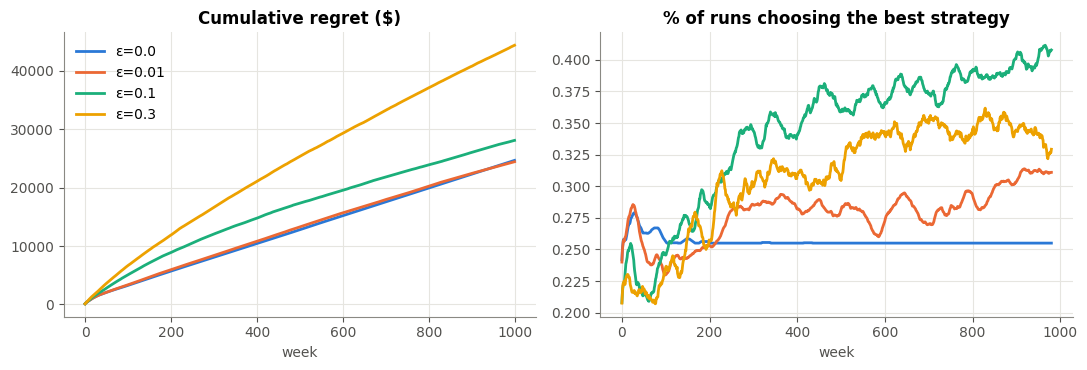

In [6]:
def eps_greedy_select(state, t, rng, eps=0.1):
    if rng.random() < eps:
        return int(rng.integers(len(state["Q"])))
    Q = state["Q"]
    return int(rng.choice(np.flatnonzero(Q == Q.max())))       # break ties randomly

results = {f"ε={e}": run_bandit(eps_greedy_select, sample_average_update, eps=e) for e in [0.0, 0.01, 0.1, 0.3]}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for i, (lab, r) in enumerate(results.items()):
    axes[0].plot(r["cum_regret"], label=lab, color=M.PALETTE[i])
    axes[1].plot(M.smooth(r["pct_optimal"], 20), label=lab, color=M.PALETTE[i])
axes[0].set_title("Cumulative regret ($)"); axes[0].set_xlabel("week")
axes[1].set_title("% of runs choosing the best strategy"); axes[1].set_xlabel("week")
axes[0].legend(); plt.tight_layout(); plt.show()

**Reading the plots.**
* **ε = 0 (pure greedy)** locks onto whatever looked good early, exactly the trap from Part 1.
  Its "% best" line goes **flat** at about 25% and never improves: it has stopped learning.
* **ε = 0.3** explores so much that it keeps paying for losing strategies: its regret grows in
  the steepest straight line.
* **ε = 0.1** finds the best strategy most often (≈ 40% of runs by the end), but its regret is
  *higher* than greedy's. Every exploratory week has a real chance of landing on an expensive
  debit spread. **In trading, exploration has a dollar price**, and with a fixed ε you pay it
  forever. That's the motivation for decaying ε, UCB and Thompson sampling below.

### 🛠 Exercise 2.3: decaying ε
Exploration is most useful early, when you know little. Implement `eps_decay_select` with
$\varepsilon_t = \min(1,\; c / (t+1))$. Try c = 5 and c = 20, and compare cumulative regret
with ε = 0.1.

*Expected:* decaying ε ends with **less** regret than fixed ε = 0.1 in the long run, because
exploration fades out. If c is too small it risks locking in early, like greedy.

In [7]:
def eps_decay_select(state, t, rng, c=10):
    # TODO: compute eps from t and c, then behave like eps_greedy_select
    return 0

**Solution**

In [8]:
def eps_decay_select(state, t, rng, c=10):
    return eps_greedy_select(state, t, rng, eps=min(1.0, c / (t + 1)))

for c in [5, 20]:
    results[f"decay c={c}"] = run_bandit(eps_decay_select, sample_average_update, c=c)
for lab in ["ε=0.1", "decay c=5", "decay c=20"]:
    print(f"{lab:11s} final regret ${results[lab]['cum_regret'][-1]:>8,.0f}   % optimal (last 100 wks) {results[lab]['pct_optimal'][-100:].mean():.0%}")

ε=0.1       final regret $  28,083   % optimal (last 100 wks) 40%
decay c=5   final regret $  23,826   % optimal (last 100 wks) 30%
decay c=20  final regret $  22,402   % optimal (last 100 wks) 42%


---
## 2.4 UCB: optimism in the face of uncertainty

**Analogy.** When you're unsure how good a new restaurant is, **assume it might be great** and
try it. Once you've eaten there enough times, your estimate is tight and the optimism goes away.

**Rule (UCB1).** Pick the arm with the highest *upper confidence bound*:

$$ a_t = \arg\max_a \Big[\, Q(a) + c\,\sqrt{\frac{\ln t}{N(a)}} \,\Big] $$

*In words:* estimated value + an **uncertainty bonus**. The bonus is large for arms you've
tried rarely (small N(a)) and shrinks as you try them. The ln t term slowly grows, so an arm
that's been ignored for a long time eventually gets another look.

*Worked example* (c = 0.5, t = 100, rewards in \$1000s):
* bull put spread: Q = 0.05, N = 60 → bonus 0.5·√(4.61/60) = 0.139 → UCB = **0.189**
* bear call spread: Q = 0.02, N = 8 → bonus 0.5·√(4.61/8) = 0.379 → UCB = **0.399** ← picked

The bear call spread gets picked, not because it looks better but because we're *unsure* about it.

**Practical catch for trading.** The right c depends on the reward's **scale and noise**.
UCB1's textbook c assumes rewards in [0, 1]. Our P&L has a std of 0.3–1.2 (in \$1000s), so we
must tune c. There's no free lunch.

In [9]:
def ucb_select(state, t, rng, c=0.5):
    N, Q = state["N"], state["Q"]
    if (N == 0).any():                                   # try every arm once first
        return int(np.flatnonzero(N == 0)[0])
    return int(np.argmax(Q + c * np.sqrt(np.log(t + 1) / N)))

for c in [0.1, 0.5, 1.0]:
    results[f"UCB c={c}"] = run_bandit(ucb_select, sample_average_update, c=c)
for lab in ["UCB c=0.1", "UCB c=0.5", "UCB c=1.0"]:
    print(f"{lab:10s} final regret ${results[lab]['cum_regret'][-1]:>8,.0f}   % optimal (last 100 wks) {results[lab]['pct_optimal'][-100:].mean():.0%}")

UCB c=0.1  final regret $  16,041   % optimal (last 100 wks) 35%
UCB c=0.5  final regret $  26,289   % optimal (last 100 wks) 33%
UCB c=1.0  final regret $  40,263   % optimal (last 100 wks) 25%


### 🛠 Exercise 2.4: reproduce the worked example
Write `ucb_score(Q, N, t, c)` and check that it gives 0.189 and 0.399 for the two arms above.

In [10]:
def ucb_score(Q, N, t, c):
    # TODO
    return None

**Solution**

In [11]:
def ucb_score(Q, N, t, c):
    return Q + c * np.sqrt(np.log(t) / N)

print(round(ucb_score(0.05, 60, 100, 0.5), 3), round(ucb_score(0.02, 8, 100, 0.5), 3))

0.189 0.399


---
## 2.5 Thompson sampling: act on a plausible world

**Analogy.** Before each decision, *imagine* one plausible version of the world, consistent
with what you've seen, and act optimally in that imagined world. Arms you're unsure about will
sometimes be imagined as great, so they get explored in proportion to the chance they really
are the best.

**Rule (Gaussian version).** For each arm, our belief about its mean is roughly
Normal(Q(a), s²(a)/N(a)): centred on the sample mean, with width shrinking like 1/√N. Draw one
sample per arm from these beliefs and pick the largest.

*Worked example.* Bull put: Q = 0.05, s = 0.32, N = 60 → belief N(0.05, 0.041²).
Long straddle: Q = −0.10, s = 0.75, N = 5 → belief N(−0.10, 0.335²). The straddle's belief is
so wide that it still has about a 33% chance of drawing above 0.05, so it keeps being tried
until its N grows.

**Why traders like it.** It explores **in proportion to the probability of being best**, and
needs no hand-tuned bonus: the noise level s(a) is estimated per arm. High-variance strategies
automatically get more samples before being judged. That is honest, but it is also expensive
when those strategies are bad. You'll see the cost below.

In [12]:
def thompson_select(state, t, rng, prior_sd=1.0):
    N, Q, S2 = state["N"], state["Q"], state["S2"]
    var = np.where(N > 1, S2 / np.maximum(N, 1) - Q ** 2, prior_sd ** 2)   # sample variance
    sd = np.sqrt(np.maximum(var, 1e-4) / np.maximum(N, 1))
    sd = np.where(N == 0, prior_sd, sd)                                     # untried → wide belief
    return int(np.argmax(rng.normal(Q, sd)))

results["Thompson"] = run_bandit(thompson_select, sample_average_update)
print(f"Thompson   final regret ${results['Thompson']['cum_regret'][-1]:>8,.0f}   % optimal (last 100 wks) {results['Thompson']['pct_optimal'][-100:].mean():.0%}")

Thompson   final regret $  33,938   % optimal (last 100 wks) 41%


---
## 2.6 Project: pick strategies on simulated P&L distributions

Compare the best version of each algorithm head to head: cumulative regret, how often each
finds the best strategy, and **which strategies each one ends up trading**.

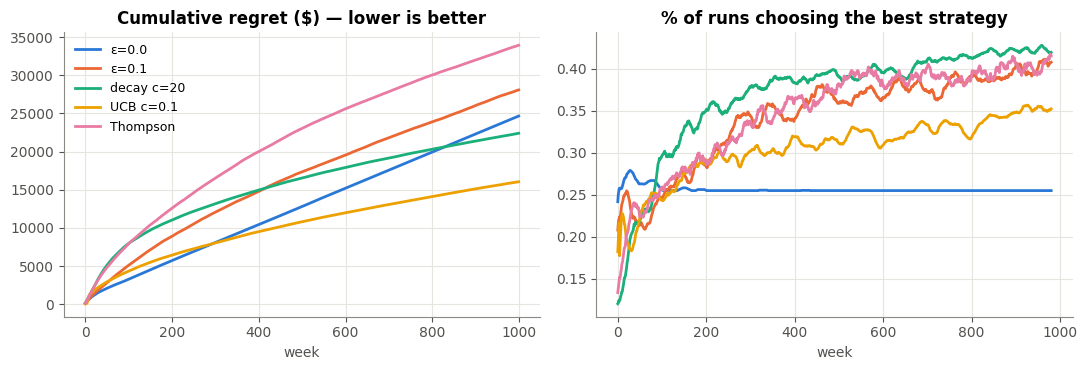

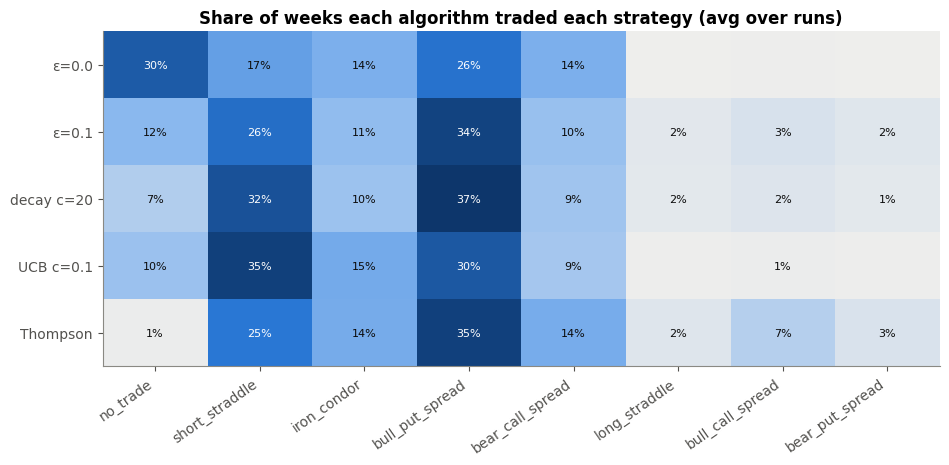

In [13]:
best = {k: results[k] for k in ["ε=0.0", "ε=0.1", "decay c=20", "UCB c=0.1", "Thompson"]}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for i, (lab, r) in enumerate(best.items()):
    axes[0].plot(r["cum_regret"], label=lab, color=M.PALETTE[i])
    axes[1].plot(M.smooth(r["pct_optimal"], 20), label=lab, color=M.PALETTE[i])
axes[0].set_title("Cumulative regret ($) — lower is better"); axes[0].set_xlabel("week")
axes[1].set_title("% of runs choosing the best strategy"); axes[1].set_xlabel("week")
axes[0].legend(fontsize=9); plt.tight_layout(); plt.show()

share = pd.DataFrame({k: v["choice_share"] for k, v in best.items()}, index=A).T
M.plot_share_matrix(share, "Share of weeks each algorithm traded each strategy (avg over runs)")
plt.show()

**What you should take away.**
* Every sensible algorithm concentrates on the premium-selling arms (bull put, short straddle).
  But separating the bull put spread from the short straddle is **hard**: their means differ by
  only about \$5 against ~\$300 of weekly noise. Even after 1,000 weeks (20 years!) no
  algorithm is sure. "% optimal" stays around 30–45%. That's the sobering truth about strategy
  research. (Regret is still low, because confusing two near-equal arms costs little.)
* **Pure greedy** (ε = 0) often gets stuck on `no_trade`. Every arm starts at Q = 0, so after
  one bad week in each strategy, "doing nothing" looks best forever, and it never learns again.
* **UCB with a small, tuned c** has the lowest regret here. With too large a c it keeps
  re-testing the losers.
* **Thompson sampling** keeps spending on the high-variance debit spreads (see the heatmap).
  Their fat tails keep its beliefs wide, so it can't rule them out quickly. Its assumption of
  Gaussian rewards doesn't match options P&L. **Know your algorithm's assumptions.**
* **The ceiling.** Even a perfect bandit only finds the single best strategy on average,
  about \$51/week. From Part 0 we know the best strategy *differs by regime*. To go beyond the
  ceiling the agent must *look at the market*. That's Part 3.

---
## 2.7 Non-stationarity: when the best arm changes

The bandit above cheated slightly: it drew weeks at random from 20 years, so the arms never
changed. Real markets move through regimes, so **the best arm drifts**. The fix is a
**constant step size** α instead of 1/n:

$$ Q \leftarrow Q + \alpha\,(R - Q) $$

*In words:* always move a fixed fraction α toward the latest reward. Old rewards fade
exponentially: a reward from *k* weeks ago has weight α(1−α)^k. With α = 0.1 a reward from 10
weeks ago still has weight 0.1·0.9¹⁰ ≈ 0.035. Its influence has shrunk by about two-thirds.

### 🛠 Exercise 2.7: replay history in order
Replay the 1,007 weeks **in chronological order** (bandit feedback: you only see the P&L of
what you picked). Compare ε-greedy (ε = 0.1) using (a) sample averages and (b) a constant α.
Report total P&L for each. Try α ∈ {0.05, 0.1, 0.2}.

*Expected:* results are noisy (one history only), so average over 20 seeds. Make a prediction
before you run it: will forgetting help?


In [14]:
def replay(alpha=None, eps=0.1, seed=0):
    rng = np.random.default_rng(seed)
    R = table.to_numpy()
    Q, N, total = np.zeros(R.shape[1]), np.zeros(R.shape[1]), 0.0
    for t in range(len(R)):
        a = int(rng.integers(len(Q))) if rng.random() < eps else int(np.argmax(Q))
        r = R[t, a] / 1000
        N[a] += 1
        # TODO: update Q[a] with 1/N[a] if alpha is None, else with alpha
        total += R[t, a]
    return total

**Solution**

In [15]:
def replay(alpha=None, eps=0.1, seed=0):
    rng = np.random.default_rng(seed)
    R = table.to_numpy()
    Q, N, total = np.zeros(R.shape[1]), np.zeros(R.shape[1]), 0.0
    for t in range(len(R)):
        a = int(rng.integers(len(Q))) if rng.random() < eps else int(np.argmax(Q))
        r = R[t, a] / 1000
        N[a] += 1
        step = 1 / N[a] if alpha is None else alpha
        Q[a] += step * (r - Q[a])
        total += R[t, a]
    return total

for alpha in [None, 0.05, 0.1, 0.2]:
    tot = np.mean([replay(alpha, seed=s) for s in range(20)])
    print(f"α={'1/n' if alpha is None else alpha:>4}: average total P&L over 20 years ${tot:>9,.0f}")
print(f"(always bull put spread, hindsight: ${table['bull_put_spread'].sum():,.0f})")

α= 1/n: average total P&L over 20 years $   16,458
α=0.05: average total P&L over 20 years $   -3,241
α= 0.1: average total P&L over 20 years $   -2,552
α= 0.2: average total P&L over 20 years $   -2,065
(always bull put spread, hindsight: $50,965)


**Surprise: forgetting *hurts* here.** Why? A constant-α estimate never stops being noisy. Its
standard deviation is about σ·√(α/(2−α)). With σ ≈ \$300 and α = 0.1 that's
300 × 0.23 ≈ **\$69**, larger than the differences between the good arms. So the agent
keeps "discovering" that a losing arm is suddenly best and switching to it.

**The lesson.** Tracking regimes by *forgetting* works only when the signal is large compared
with the noise. With weekly options P&L it usually isn't. A better way to handle regimes is to
**observe them**: feed the market features in, and learn "which strategy works *when*". That's
exactly what a contextual bandit does.

## Recap
* Bandit = choose among arms with unknown payoffs. Learn with the incremental update
  **Q ← Q + step × (R − Q)**.
* **ε-greedy**: simple, but never stops paying for exploration. **UCB**: optimism bonus
  ~ √(ln t / N). **Thompson**: sample a plausible world. It adapts to each arm's noise.
* Options P&L is noisy and fat-tailed. High-variance strategies fool naive learners, and
  separating close competitors takes years of data.
* A context-free bandit can only find the best strategy **on average**. To pick the best
  strategy **for this week's market**, the agent needs context.

**Next → Part 3:** contextual bandits, your first regime-aware selector.